# FARGO3D

| Author  | Stanley A. Baronett  |
|---------|----------------------|
| Created |  05/26/2026          |
| Updated |  05/26/2026          |

In [3]:
#===============================================================================
import matplotlib.pyplot as plt
import matplotlib.colors as colors
from matplotlib.patches import FancyArrowPatch
from mpl_toolkits.axes_grid1 import AxesGrid
import numpy as np
import pandas as pd

root = '..'
reses = [512, 1024]
res = reses[-1]
n_p = 'np1'
runs = {
    # f'dust_particles/{n_p}': {
    #     'ls': 'dotted',
    #     'codes' : {
    #         'Athena':       'tab:green',
    #         'Athena++':     'tab:red',
    #         'Pencil':       'tab:blue',
    #         'PLUTO':        'tab:pink'
    #     }
    # },
    'dust_fluid': {
        'ls': 'solid',
        'codes' : {
            # 'Athena++':     'tab:purple',
            'FARGO3D':      'tab:purple',
            # 'Idefix':       'tab:orange',
            # 'LA-COMPASS':   'tab:cyan',
            # 'PLUTO':        'tab:brown'
        }
    }
}

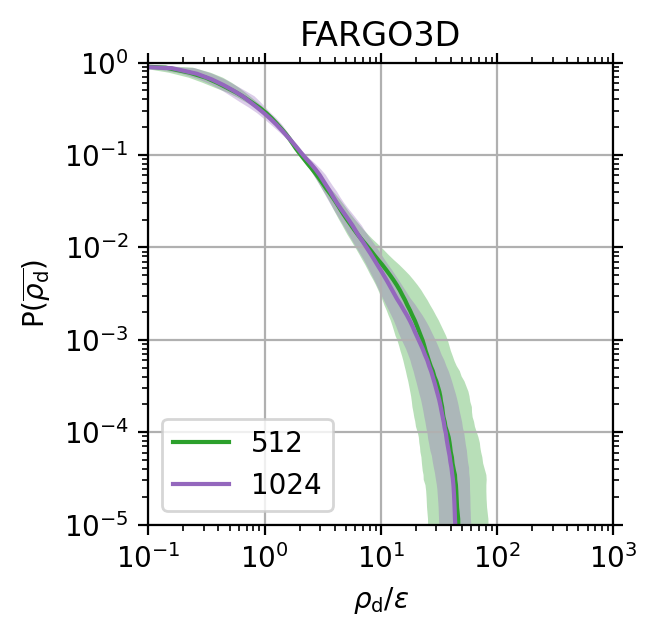

In [9]:
#===============================================================================
times = [20, 50, 100]  # [T]

# Plot
fig, ax = plt.subplots(figsize=(3, 3), dpi=200)
epsilon = 0.2

for res in reses:
    indices = -np.unique(np.logspace(np.log2(res**2), 0, num=100, base=2,
                         dtype=int))
    for key, value in runs.items():
        for code, color in value['codes'].items():
            path = f'{root}/{res}/src/{key}/{code}'
            rhods = []
            for i, time in enumerate(times):
                snapshot = np.load(f'{path}/{time}.npz')
                sort = np.sort(snapshot['rhod'], axis=None)
                rhods.append(sort)
            rhods = np.asarray(rhods)
            avgs = np.average(rhods, axis=0)
            cdf = np.linspace(1, 0, avgs.size, endpoint=False)
            log = np.log(np.clip(rhods, 1e-45, None))
            std_log = np.std(log, axis=0)
            stds = np.clip(np.exp(std_log), None, 3)
            cdf = np.take_along_axis(cdf, indices, 0)
            avgs = np.take_along_axis(avgs, indices, 0)
            stds = np.take_along_axis(stds, indices, 0)
            if res == 512:
                ax.plot(avgs/epsilon, cdf, color='tab:green',
                        ls=value['ls'], label='512')
                ax.fill_betweenx(cdf, avgs/stds/epsilon, avgs*stds/epsilon,
                                 alpha=1/3, color='tab:green', ec=None)
            else:
                ax.plot(avgs/epsilon, cdf, color='tab:purple', label='1024')
                ax.fill_betweenx(cdf, avgs/stds/epsilon, avgs*stds/epsilon,
                                 alpha=0.33, color='tab:purple', ec=None)
#===============================================================================

# Format plots
ax.grid()
ax.legend(loc='lower left')
ax.minorticks_on()
ax.set(xscale='log', yscale='log')
ax.tick_params(axis='both', which='both', top=True, right=True)
ax.set(title='FARGO3D', xlim=(0.1, 1e3), xlabel=r'$\rho_\mathrm{d}/\epsilon$',
       ylim=(1e-5, 1), ylabel=r'P$(\overline{\rho_\mathrm{d}})$')
fig.subplots_adjust(hspace=0)
plt.savefig(f'figs/CDF-FARGO3D.svg', bbox_inches='tight',
            pad_inches=0.01)
#===============================================================================

512² FARGO3D samples
	  Total: 631
	Strided: 631
	Per 10T: 63
1024² FARGO3D samples
	  Total: 628
	Strided: 628
	Per 10T: 69


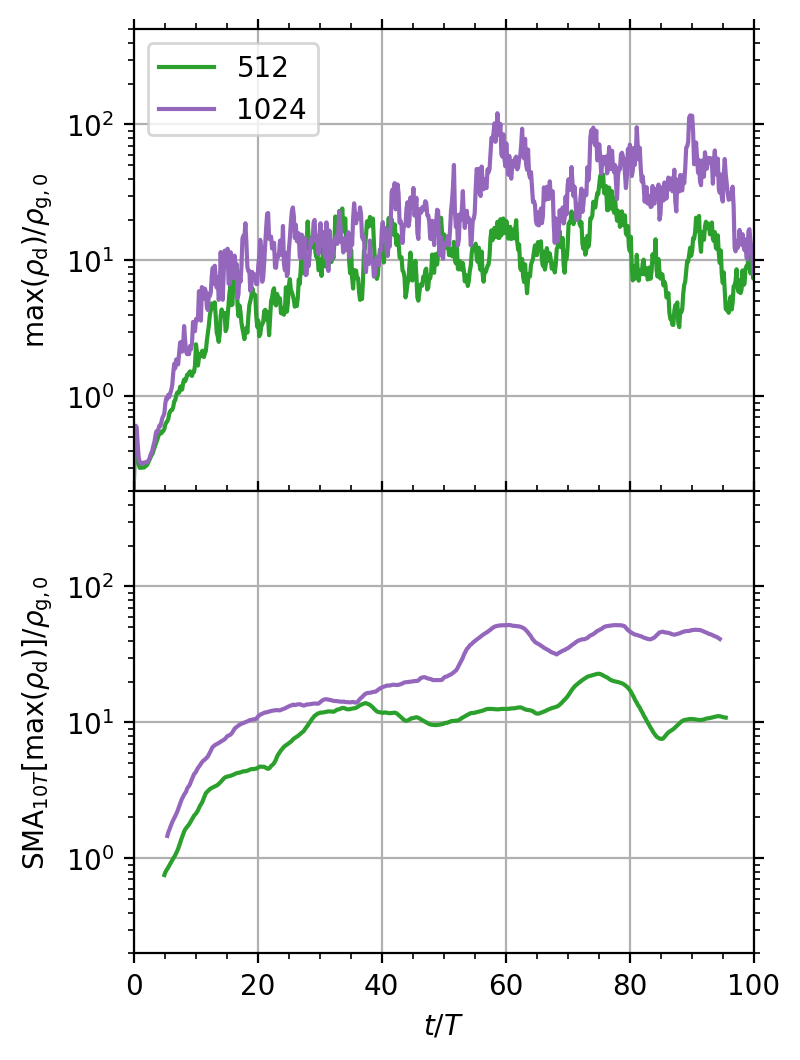

In [8]:
#===============================================================================
def print_samples(res, code, t, step, dt, window):
    """Print the number of samples in the time series."""
    print(f'{res}² {code} samples\n=======================')
    print(f'\t  Total: {len(t)}')
    print(f'\tStrided: {len(t[::step])}')
    print(f'\tPer {dt}T: {window}')

diag = True
dt = 10  # [T]

# Lowest cadence
path = f'../{res}/src/dust_fluid/FARGO3D'
n_min = len(np.load(f'{path}/time_series.npz')['t'])

# Plot
fig, axs = plt.subplots(nrows=2, sharex=True, figsize=(4, 6), dpi=200)
for res in reses:
    for k, (key, value) in enumerate(runs.items()):
        for code, color in value['codes'].items():
            path = f'{root}/{res}/src/{key}/{code}'
            data = np.load(f'{path}/time_series.npz')
            t = data['t']
            step = len(t)//n_min
            if res == 512:
                color = 'tab:green'
            else:
                color = 'tab:purple'
            # Strided
            if step < 2:
                step = 1 if len(t)%n_min/n_min < 0.5 else 2
            try:
                axs[0].plot(t[::step], data['maxrhod'][::step], color=color,
                            label=res)
            except KeyError:
                print(code)
            # SMA
            window = len(t)//int(t[-1]/dt)
            print_samples(res, code, t, step, dt, window) if diag else None
            df = pd.DataFrame(data=data['maxrhod'], index=t)
            df['sma'] = df.rolling(window, center=True).mean()
            axs[1].plot(df['sma'], color=color)

# Format plots
for k, ax in enumerate(axs):
    ax.grid()
    ax.minorticks_on()
    ax.set(yscale='log')
    ax.tick_params(axis='both', which='both', top=True, right=True)
axs[0].legend()
axs[0].set(ylabel=rf'$\max(\rho_\mathrm{{d}})/\rho_\mathrm{{g,0}}$', ylim=(2e-1, 5e2))
axs[1].set(xlabel=r'$t/T$', xlim=(0, 100), ylim=(2e-1, 5e2),
           ylabel=rf'$\mathrm{{SMA}}_{{{dt}T}}[\max(\rho_\mathrm{{d}})]/\rho_\mathrm{{g,0}}$')
fig.subplots_adjust(hspace=0)
plt.savefig(f'figs/time_series-FARGO3D.svg',
            bbox_inches='tight', pad_inches=0.01)
#===============================================================================

## Data compliance

### FARGO3D

In [ ]:
import numpy as np

root = f'/home/stanley/github/pfitsplus/sicc/data'
model = 'unstratified'
problem = 'BA'
dust = 'fluid'
n_p = ''
res = 1024
variation = f'{res}/dust_{dust}/{n_p}'
code = 'FARGO3D'
prefix = 'dust1dens'
suffix = '.dat'
path = f'{root}/{model}/{problem}/{variation}/{code}'
times = [5, 10, 20, 50, 100]

# Load separate grid
snapshot = np.load(f'{path}/old/0.npz', mmap_mode='r')
x = snapshot['x']
z = snapshot['z']

# Inspect
# np.fromfile(f'{path}/old/{prefix}{times[0]}{suffix}').reshape(1024,1024)

# # Standardize
for time in times:
    rhod = np.fromfile(f'{path}/old/{prefix}{time}{suffix}').reshape(1024,1024)
    np.savez_compressed(f'{path}/{time}', x=x, z=z, rhod=rhod)

In [ ]:
import numpy as np

root = f'/home/stanley/github/pfitsplus/sicc/data'
model = 'unstratified'
problem = 'BA'
dust = 'fluid'
n_p = ''
res = 1024
variation = f'{res}/dust_{dust}/{n_p}'
code = 'FARGO3D'
# fname = 'data_time_dust_ratio_series.npz'
path = f'{root}/{model}/{problem}/{variation}/{code}'

# Inspect
time_series = np.load(f'{path}/old/time_series1024.npz', mmap_mode='r')

# Standardize
inverse_omega = time_series['arr_0']
maxrhod = time_series['arr_1']
np.savez_compressed(f'{path}/time_series', t=inverse_omega/2/np.pi,
                    maxrhod=maxrhod)
